# Inspeccion de los datos

Los datos vienen en 393 archivos parquet para la train data y 3 parquet para la validacion.

Vamos a seleccionar uno e inspeccionamos como se ven.

Una posible alternativa a como tratar los datos va a ser probar webdataset que enteoria se trabaja mas eficientemente

In [3]:
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from io import BytesIO

d:\facuult\geo-proy\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import matplotlib.pyplot as plt

In [5]:
RUTA_PARQUET = r"E:\google_street_view\train-00000-of-00393.parquet"

# Cargamos el Parquet como Dataset de Hugging Face
ds_hf = load_dataset(
    "parquet",
    data_files=RUTA_PARQUET,
    split="train"
)

print(ds_hf)
print(ds_hf.column_names)

Dataset({
    features: ['image_id', 'panoid', 'image', 'country_code', 'date', 'latitude', 'longitude', 'elevation'],
    num_rows: 5087
})
['image_id', 'panoid', 'image', 'country_code', 'date', 'latitude', 'longitude', 'elevation']


Vamos a ver como luce una secuencia de fotos

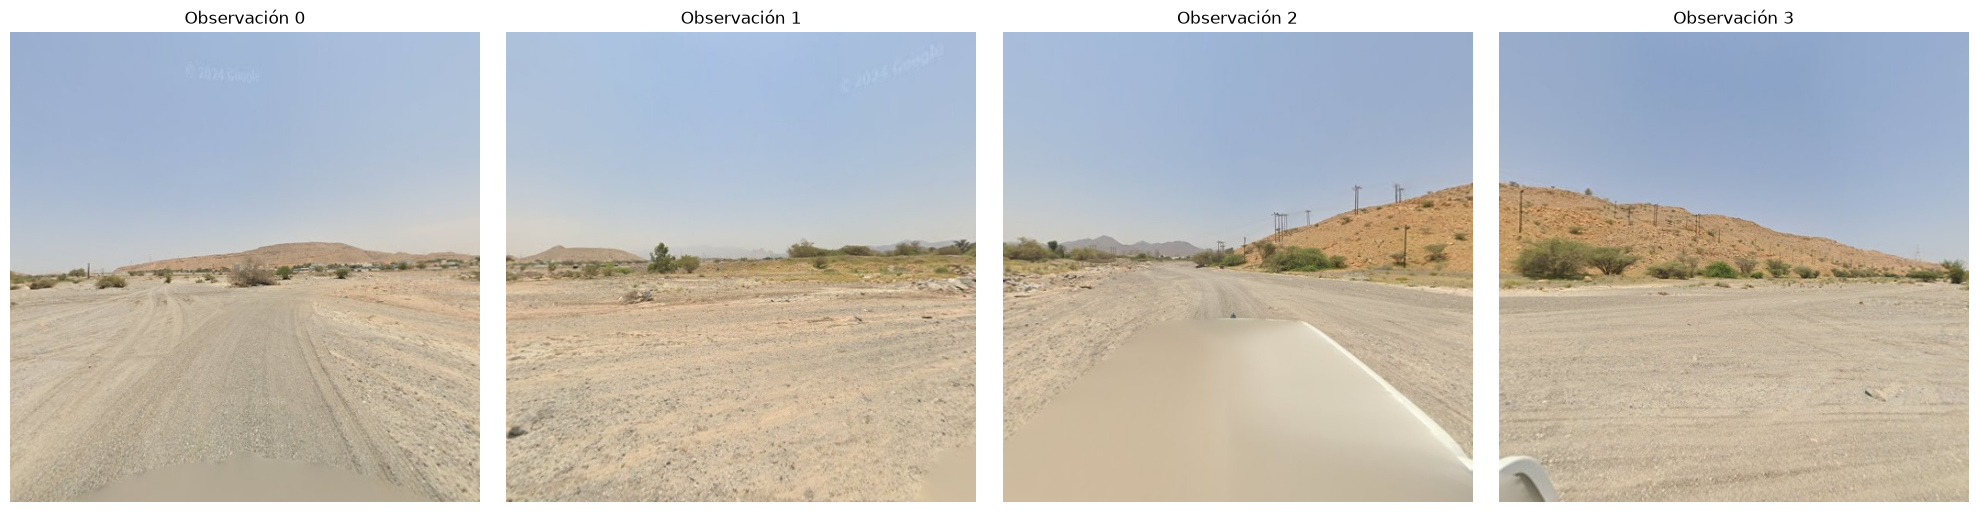

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i in range(4):
    imagen = ds_hf[i]["image"]

    axes[i].imshow(imagen)
    axes[i].set_title(f"Observación {i}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

# Verificaicon de panos id
Todo en orden pueden estar en diferentes panos_id si queda ultima secuencia. Habria que verificar si todos los panos id agrupados de a 4 suman 4 efectivamente.

verificamos si todas en este dataset tienen 4 pano id. Pareciera que no, ene ste dataset.

In [7]:
print(ds_hf["panoid"])

from collections import Counter

conteo_panoid = Counter()

for panoid in ds_hf["panoid"]:
    conteo_panoid[panoid] += 1

print("Cantidad de panoids:", len(conteo_panoid))

# Mostrar los primeros 20
for panoid, cantidad in list(conteo_panoid.items())[::-1]:
    print(panoid, "->", cantidad)

Column(['Wbol3_26rV5C8zNOQrzTjw', 'Wbol3_26rV5C8zNOQrzTjw', 'Wbol3_26rV5C8zNOQrzTjw', 'Wbol3_26rV5C8zNOQrzTjw', 'juB6Vsgccaj7A_F46AT3MQ', ...])
Cantidad de panoids: 1272
NtPw7VjfZW35tlMYGXeRqg -> 3
_pTBim4dwvvmaHdFXOzuUw -> 4
KP-4c2vYJmB4razO3vkj1g -> 4
fRdRDaZXLZo3_nX3khbfFQ -> 4
ZZzNgjGEaqHn-RVeo9JAWw -> 4
U4WVrlT2jUfVxXL3Vsxmyw -> 4
QddgS5N0j6GghrDTciKpJg -> 4
S1mDj0X9GdQbOAYNah4gGA -> 4
yPTuWFGvLPS0RPTPeFHfKg -> 4
RPUNB2Fw4l7ljONjs4n5Mw -> 4
kWvjEuaekTL5a8n8DHSbPg -> 4
b5k7giGr94oMyoleWpQpcQ -> 4
I71bKXOKCMgVtXg_dvk50Q -> 4
N0JdgmYzEkXfCg8drZG3Ng -> 4
aM3cUPxh2ZxrHDcWRdzDgw -> 4
izdxJ5EWCVaOHiGfVeF-Iw -> 4
DLRzsnXTH3iSnkFjOQZV_A -> 4
_6vegOY1hAHCwXnIrVyagg -> 4
LubWBBzOl1Rufauj2272bA -> 4
5WUKf-TybpiQnZczT4e70Q -> 4
t-LtOxdh-d6Iwu2VwehO7w -> 4
V-ZBuOaf36bZqmJxD-I1mw -> 4
Bhcqmy3cqM16hVi63Yz4Qw -> 4
JqIgMLtEAt_5UG0XgVtgUg -> 4
XwFxnkZI3QeIQy6Tv9ss9g -> 4
OJpzT1ZlNHtt-W2QOzr0ng -> 4
BZYRZDXfppH1qrtAmjMBjw -> 4
nVKHyfeUTQkhOegc6uBSOg -> 4
shV7_gdWSmOtYpvRqSs2HA -> 4
DtOX-WVhuca8IWTsHi

Pareciera faltar uno. Me voy a fijar si esta en el parquet siguiente quizas sea la ultima observacion

In [8]:
RUTA_PARQUET = r"E:\google_street_view\train-00001-of-00393.parquet"

# Cargamos el Parquet como Dataset de Hugging Face
ds_hf2 = load_dataset(
    "parquet",
    data_files=RUTA_PARQUET,
    split="train"
)

print(ds_hf2)
print(ds_hf2.column_names)


Dataset({
    features: ['image_id', 'panoid', 'image', 'country_code', 'date', 'latitude', 'longitude', 'elevation'],
    num_rows: 5087
})
['image_id', 'panoid', 'image', 'country_code', 'date', 'latitude', 'longitude', 'elevation']


In [9]:
conteo_panoid = Counter()

for panoid in ds_hf2["panoid"]:
    conteo_panoid[panoid] += 1

print("Cantidad de panoids:", len(conteo_panoid))

# Ordenados por cantidad de observaciones, de menor a mayor
for panoid, cantidad in sorted(conteo_panoid.items(), key=lambda x: x[1]):
    print(panoid, "->", cantidad)

Cantidad de panoids: 1273
NtPw7VjfZW35tlMYGXeRqg -> 1
FKdkpXRDpjWdAxMEzv8NoA -> 2
rm07RfdbgVHkbtccK7KjCA -> 4
vZ3CA2qkycXME0xUxyBB0w -> 4
r1aiY_5gnl21FCKiwvQSfg -> 4
Zj3tV_BsLEOhAbTJIKo0xA -> 4
8jkKZ-VUp77TmsCu7U62Pw -> 4
7ATeQFWOD9p2-2al6-X4dQ -> 4
WKmw7yOyHpCXkmB9GeBFPg -> 4
oIAVhdj1DJfz-7RJM__1Yw -> 4
MPZRE1tPY1CCf8D3ML__Pg -> 4
KX-eSiwtOhLzDZ-pgAEF6g -> 4
QsATMsjT7s58naf0D-37uw -> 4
Qz6b80M7cAdnnXOEjKhm0g -> 4
Ao8LFNkAOQJzGHV8CwacsQ -> 4
7A1Q-YeaGOFepBviT3BqUw -> 4
_5iVLScTe5DeDcHIve1law -> 4
P6ssT7J0YLJpuD58JSEZ0w -> 4
Qf_W3QayinwFjPjSLQplrw -> 4
-5vKMuZ7_5KMEkCQqR4OuQ -> 4
unZh6OYZ-2zwEHQlOUPFJQ -> 4
yaxHQnOEMIfYJFBGo86XKQ -> 4
bD6bnU4yCjt0MDNxcMCrfA -> 4
X-JsqziIjGvL8em75ZUOQw -> 4
GG9ZOOKInp15EIdAqnIeDg -> 4
oYdmwm4gMXEzZDBqDIdYuw -> 4
tYi8vfiNZLb9uA31REXHmw -> 4
o9p3vDBoMzBLriircuE_uw -> 4
bb42DJMMaGYQ2INbx_Rahg -> 4
iIvBGnHhtVkbkcIFX0uivQ -> 4
SEcs0Qjxv45mvsTzAQ3GYA -> 4
oDXSznYOnuu8IdrMzuBsVA -> 4
NF8vAnWsShTrPx5lKx-i2A -> 4
fmRVOTB0OsAjWBZjLnfotg -> 4
sKE1wLCw4PDa8SBZ6gEa8A

En efecto la observacion que faltaba estabea en el parquet siguiente y podemos intuir lo mismo en todas (habria que hacer un analisis exaustivo de ello)

# Isocode faltante

Habia features que cuando la agrupamos en `datasets>world-streetveiw-500k>visualization` no se agrupaban con ningun isocode. Vamos a buscar alguno de estos casos para ver si podemos ver si tienen las coordenadas latitud y longitud almenos

In [10]:
coordenadas = {}

for dataset in [ds_hf, ds_hf2]:

    for i in range(len(dataset)):
        dato = dataset[i]

        if dato["country_code"] is None:
            panoid = dato["panoid"]

            if panoid not in coordenadas:
                coordenadas[panoid] = (
                    dato["latitude"],
                    dato["longitude"]
                )

print(f"Panoids encontrados: {len(coordenadas)}")

for panoid, coordenadas_punto in coordenadas.items():
    print(panoid, "->", coordenadas_punto)

Panoids encontrados: 18
nStPiWunXzLpmRJ5RJtcJQ -> (18.46862067171511, -92.69660881345912)
JIH0k_FP7EO7bcluoKLsbA -> (-33.53880804373794, 18.85719998518091)
c_tPt2e8EBwraqvdt2X--g -> (34.82106766448096, -109.8511755819142)
8uyG3qSAHW3PkB6dKQDOAA -> (44.68275268508718, -123.2111401676314)
9QyitKIn-c9vMoX7g6ec6g -> (51.55434960933135, -1.471764289463521)
2zMLfZ8hPcLdQ0kGALwcpw -> (-43.49299175968077, 171.5418720588266)
KxFlPSwJTDuTwspAC3pxhw -> (51.42239103972092, 30.06446406753992)
Bsc8tziRNLqzFEYHCavzyg -> (37.59973399594084, -110.0172245490053)
LeS2R2ILu1fsQAca6wqPDA -> (53.91136874766215, -8.012309769297737)
JH856a50VwuQS2CrWJGHig -> (39.12924398727694, -86.35078249306004)
DWtxcXbv3Ad6pkRMBmoWfA -> (43.40650852884212, 142.6739325202844)
wk2jWTDO5ndks8-AIZ2dUw -> (-22.37138980648678, -44.68267837376857)
6CmK8qvd_rAERtAfkBK4iw -> (47.45677812197538, 92.13715499709869)
F2wBKCVL73BEuUbMd9y9-Q -> (35.28015130178065, -111.6216836980026)
ygpivy6BfJuSe4xYuo13rA -> (42.13349913473426, 74.08074

Vemos que tienen latitud y longitud para estos datasets a pesar de no tener. Existe una libreria geopy que tiene una funcion que dada unas coordenadas retorna  el pais al que pertenece.

In [11]:
from geopy.geocoders import Nominatim
import time

geolocator = Nominatim(user_agent="geo-proy")

for panoid, (lat, lon) in coordenadas.items():

    ubicacion = geolocator.reverse((lat, lon),language="en",zoom=3, timeout=10)

    if ubicacion is not None:
        address = ubicacion.raw.get("address", {})
        pais = address.get("country")
        country_code = address.get("country_code")

        print(panoid,"->",lat,lon,"->",pais,country_code.upper() if country_code else None)

    else:
        print(panoid, "-> No encontrado")

    time.sleep(1)

nStPiWunXzLpmRJ5RJtcJQ -> 18.46862067171511 -92.69660881345912 -> Mexico MX
JIH0k_FP7EO7bcluoKLsbA -> -33.53880804373794 18.85719998518091 -> South Africa ZA
c_tPt2e8EBwraqvdt2X--g -> 34.82106766448096 -109.8511755819142 -> United States US
8uyG3qSAHW3PkB6dKQDOAA -> 44.68275268508718 -123.2111401676314 -> United States US
9QyitKIn-c9vMoX7g6ec6g -> 51.55434960933135 -1.471764289463521 -> United Kingdom GB
2zMLfZ8hPcLdQ0kGALwcpw -> -43.49299175968077 171.5418720588266 -> New Zealand NZ
KxFlPSwJTDuTwspAC3pxhw -> 51.42239103972092 30.06446406753992 -> Ukraine UA
Bsc8tziRNLqzFEYHCavzyg -> 37.59973399594084 -110.0172245490053 -> United States US
LeS2R2ILu1fsQAca6wqPDA -> 53.91136874766215 -8.012309769297737 -> Ireland IE
JH856a50VwuQS2CrWJGHig -> 39.12924398727694 -86.35078249306004 -> United States US
DWtxcXbv3Ad6pkRMBmoWfA -> 43.40650852884212 142.6739325202844 -> Japan JP
wk2jWTDO5ndks8-AIZ2dUw -> -22.37138980648678 -44.68267837376857 -> Brazil BR
6CmK8qvd_rAERtAfkBK4iw -> 47.456778121975

Confiamos ciegamente que estan bien así que no sería un problema esto wiwiwiwi

# construcción de los datasets

Para construir un Dataset de pytorch, la secuencia de datos viene ordenada donde cada foto (que pueden quedar en diferente parquet) a 0°, 90°, 180°, 270° respecto al norte. Vamos a agrupar por panoid.

Vamos a plantear dos datasets de muestras, una para clasificaicon de paises para predecir el country code y otra para regresion para estimar las coordenadas.

In [12]:
from pathlib import Path

RUTA_DATA = Path(r"E:\google_street_view")#path absoluto de donde estan las imagenes

RUTAS_SHARDS = sorted(RUTA_DATA.glob("train-*-of-00393.parquet"))

print(f"Shards encontrados: {len(RUTAS_SHARDS)}")
print(RUTAS_SHARDS[0])
print(RUTAS_SHARDS[-1])

Shards encontrados: 2
E:\google_street_view\train-00000-of-00393.parquet
E:\google_street_view\train-00001-of-00393.parquet


Ambos codigos los guardaremos en `objects/StreetViewDatasetsModels.py` como modelos.

In [13]:
from torch.utils.data import Dataset


class StreetViewClassifyDataset(Dataset):

    def __init__(self, samples, datasets, transform=None):
        self.samples = samples
        self.datasets = datasets
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        muestra = self.samples[idx]

        imagenes = []

        for dataset_id, fila in muestra["references"]:

            imagen = self.datasets[dataset_id][fila]["image"]

            if self.transform is not None:
                imagen = self.transform(imagen)

            imagenes.append(imagen)

        country_code = muestra["country_code"]

        return imagenes, country_code

In [15]:
from collections import defaultdict
datasets = {
    "ds_hf": ds_hf,
    "ds_hf2": ds_hf2
}

muestras_por_panoid = defaultdict(list)


for dataset_id, dataset in datasets.items():

    for i in range(len(dataset)):

        dato = dataset[i]

        muestras_por_panoid[dato["panoid"]].append({
            "dataset_id": dataset_id,
            "fila": i,
            "country_code": dato["country_code"],
            "latitude": dato["latitude"],
            "longitude": dato["longitude"]
        })


print("Panoids encontrados:", len(muestras_por_panoid))

Panoids encontrados: 2544


In [16]:
samples = []


for panoid, observaciones in muestras_por_panoid.items():

    # Queremos exactamente las 4 vistas
    if len(observaciones) != 4:
        continue

    # No podemos entrenar clasificación si no conocemos el país
    if any(obs["country_code"] is None for obs in observaciones):
        continue

    # Verificamos que las 4 observaciones tengan el mismo país
    paises = set(obs["country_code"] for obs in observaciones)

    if len(paises) != 1:
        continue

    samples.append({
        "panoid": panoid,

        "references": [
            (obs["dataset_id"], obs["fila"])
            for obs in observaciones
        ],

        "country_code": observaciones[0]["country_code"]
    })


print("Samples completos:", len(samples))

Samples completos: 2525


In [17]:
from torch.utils.data import Dataset


class StreetViewClassifyDataset(Dataset):

    def __init__(self, samples, datasets, transform=None):
        self.samples = samples
        self.datasets = datasets
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        muestra = self.samples[idx]

        imagenes = []

        for dataset_id, fila in muestra["references"]:

            imagen = self.datasets[dataset_id][fila]["image"]

            if self.transform is not None:
                imagen = self.transform(imagen)

            imagenes.append(imagen)

        country_code = muestra["country_code"]

        return imagenes, country_code

In [18]:
imagen = ds_hf[0]["image"]

print(type(imagen))
print(imagen.size)

<class 'PIL.JpegImagePlugin.JpegImageFile'>
(512, 512)


In [19]:
from torchvision import transforms


transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor()
])

In [20]:
dataset_classify = StreetViewClassifyDataset(
    samples=samples,
    datasets=datasets,
    transform=transform
)

imagenes, pais = dataset_classify[0]

print(len(imagenes))
print(imagenes[0].shape)
print(pais)

4
torch.Size([3, 512, 512])
OM


In [21]:
paises = sorted(set(sample["country_code"] for sample in samples))

country_to_idx = {
    pais: i
    for i, pais in enumerate(paises)
}

idx_to_country = {
    i: pais
    for pais, i in country_to_idx.items()
}

num_classes = len(paises)

print("Cantidad de países:", num_classes)
print(country_to_idx)

Cantidad de países: 79
{'AE': 0, 'AR': 1, 'AT': 2, 'AU': 3, 'BA': 4, 'BD': 5, 'BE': 6, 'BG': 7, 'BO': 8, 'BR': 9, 'BW': 10, 'CA': 11, 'CH': 12, 'CL': 13, 'CO': 14, 'CR': 15, 'CZ': 16, 'DE': 17, 'DK': 18, 'EC': 19, 'EE': 20, 'ES': 21, 'FI': 22, 'FR': 23, 'GB': 24, 'GR': 25, 'GT': 26, 'HK': 27, 'HR': 28, 'HU': 29, 'ID': 30, 'IE': 31, 'IN': 32, 'IS': 33, 'IT': 34, 'JE': 35, 'JP': 36, 'KE': 37, 'KH': 38, 'KR': 39, 'KZ': 40, 'LK': 41, 'LT': 42, 'LU': 43, 'LV': 44, 'ME': 45, 'MN': 46, 'MX': 47, 'MY': 48, 'NA': 49, 'NG': 50, 'NL': 51, 'NO': 52, 'NP': 53, 'NZ': 54, 'OM': 55, 'PA': 56, 'PE': 57, 'PH': 58, 'PL': 59, 'PR': 60, 'PT': 61, 'QA': 62, 'RO': 63, 'RS': 64, 'RU': 65, 'RW': 66, 'SE': 67, 'SI': 68, 'SK': 69, 'SN': 70, 'TH': 71, 'TR': 72, 'TW': 73, 'UA': 74, 'US': 75, 'UY': 76, 'VN': 77, 'ZA': 78}


In [29]:
from torch.utils.data import Dataset
import torch


class StreetViewClassifyDataset(Dataset):

    def __init__(
        self,
        samples,
        datasets,
        country_to_idx,
        transform=None
    ):
        self.samples = samples
        self.datasets = datasets
        self.country_to_idx = country_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        muestra = self.samples[idx]

        imagenes = []

        for dataset_id, fila in muestra["references"]:

            imagen = self.datasets[dataset_id][fila]["image"]

            if self.transform is not None:
                imagen = self.transform(imagen)

            imagenes.append(imagen)

        country_code = muestra["country_code"]

        label = torch.tensor(
            self.country_to_idx[country_code],
            dtype=torch.long
        )

        return imagenes, label

In [31]:
import torch
import torch.nn as nn


class StreetViewCNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.encoder = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):

        # x:
        # [batch, 4, 3, 512, 512]

        batch_size = x.shape[0]

        features = []

        for i in range(4):

            imagen = x[:, i]

            feature = self.encoder(imagen)

            feature = feature.view(batch_size, -1)

            features.append(feature)

        # [batch, 4, 256]
        features = torch.stack(features, dim=1)

        # Combinamos las 4 vistas
        features = features.mean(dim=1)

        # [batch, 256]
        salida = self.classifier(features)

        return salida

In [33]:
from sklearn.model_selection import train_test_split

samples_train, samples_test = train_test_split(
    samples,
    test_size=20,
    random_state=42
)

print("Train:", len(samples_train))
print("Test:", len(samples_test))

Train: 2505
Test: 20


In [34]:
dataset_train = StreetViewClassifyDataset(
    samples=samples_train,
    datasets=datasets,
    country_to_idx=country_to_idx,
    transform=transform
)

dataset_test = StreetViewClassifyDataset(
    samples=samples_test,
    datasets=datasets,
    country_to_idx=country_to_idx,
    transform=transform
)

In [35]:
from torch.utils.data import DataLoader

loader_train = DataLoader(
    dataset_train,
    batch_size=4,
    shuffle=True
)

loader_test = DataLoader(
    dataset_test,
    batch_size=4,
    shuffle=False
)

In [36]:
imagenes, labels = next(iter(loader_train))

print("Cantidad de vistas:", len(imagenes))
print("Shape de cada vista:", imagenes[0].shape)
print("Labels:", labels)
print("Shape labels:", labels.shape)

Cantidad de vistas: 4
Shape de cada vista: torch.Size([4, 3, 512, 512])
Labels: tensor([36, 53,  3, 32])
Shape labels: torch.Size([4])


In [37]:
x = torch.stack(imagenes, dim=1)

print("Shape de X:", x.shape)

Shape de X: torch.Size([4, 4, 3, 512, 512])


In [38]:
import torch
import torch.nn as nn

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

modelo = StreetViewCNN(
    num_classes=len(country_to_idx)
).to(device)

print("Device:", device)

criterio = nn.CrossEntropyLoss()

optimizador = torch.optim.Adam(
    modelo.parameters(),
    lr=1e-3
)

Device: cpu


In [39]:
n_epocas = 3

for epoca in range(n_epocas):

    modelo.train()

    perdida_total = 0.0

    for imagenes, labels in loader_train:

        # [B, 4, 3, 512, 512]
        x = torch.stack(imagenes, dim=1)

        x = x.to(device)
        labels = labels.to(device)

        optimizador.zero_grad()

        salida = modelo(x)

        perdida = criterio(salida, labels)

        perdida.backward()

        optimizador.step()

        perdida_total += perdida.item()

    perdida_promedio = perdida_total / len(loader_train)

    print(
        f"Época {epoca + 1}/{n_epocas} "
        f"- pérdida: {perdida_promedio:.4f}"
    )

Época 1/3 - pérdida: 3.3658
Época 2/3 - pérdida: 3.2518
Época 3/3 - pérdida: 3.2341


In [40]:
modelo.eval()

correctas = 0
total = 0

with torch.no_grad():

    for imagenes, labels in loader_test:

        x = torch.stack(imagenes, dim=1)

        x = x.to(device)
        labels = labels.to(device)

        salida = modelo(x)

        predicciones = salida.argmax(dim=1)

        correctas += (predicciones == labels).sum().item()
        total += labels.size(0)

precision = correctas / total

print(f"Test accuracy: {precision:.4f}")
print("porcentaje de acierto ante datos que nunca vio")

Test accuracy: 0.2000
porcentaje de acierto ante datos que nunca vio
